# AlexNet Implementation

This notebook implements an AlexNet-style convolutional neural network for CIFAR-10.

The original AlexNet processed much larger ImageNet images. CIFAR-10 images are only 32 × 32 pixels, so the convolution sizes and fully connected layers must be adapted. The model still retains the central AlexNet structure:

- Five convolutional layers
- ReLU activations
- Three fully connected layers
- Overlapping max pooling
- Dropout


In [19]:
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [20]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Input: 3 × 32 × 32
            nn.Conv2d(
                in_channels=3,
                out_channels=96,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            # 96 × 16 × 16
            nn.Conv2d(
                in_channels=96,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            # 256 × 8 × 8
            nn.Conv2d(
                in_channels=256,
                out_channels=384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=384,
                out_channels=384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=384,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 2 * 2, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [21]:
model = AlexNetCIFAR10().to(device)

print(model)

AlexNetCIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(2, 2))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=1024, out_features=1024, bias=Tr

In [22]:
test_batch = torch.randn(8, 3, 32, 32).to(device)

with torch.no_grad():
    output = model(test_batch)

print("Input shape:", test_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([8, 3, 32, 32])
Output shape: torch.Size([8, 10])


In [23]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 4,901,258
Trainable parameters: 4,901,258


## Differences from the original AlexNet

Original AlexNet: ~224×224 ImageNet images, 11×11 first conv. That kernel would wreck a 32×32 CIFAR-10 image almost instantly, so this version uses 3×3 convs throughout instead — same five-conv, three-linear-layer structure, just scaled down. Classifier is smaller too (10 classes vs. 1000).

Call this an AlexNet-style adaptation, not a reproduction.

In [24]:
criterion = nn.CrossEntropyLoss()  # measures prediction error using raw logits and correct class labels

optimizer = torch.optim.SGD(
    model.parameters(),   # the model's weights and biases to update
    lr=0.01,              # learning rate: controls the size of each update
    momentum=0.9,         # uses past gradients to smooth and build up updates
    weight_decay=0.0005   # l2 regularization: discourages large parameter values
)

In [ ]:
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

project_directory = Path.cwd()  # Current working folder

if project_directory.name == "notebooks":
    project_directory = project_directory.parent  # Go up to alexnet-study

preprocess = transforms.Compose([
    transforms.ToTensor(),  # Convert pixels to a tensor with values from 0 to 1
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )  # Rescale each colour channel from [0, 1] to [-1, 1]
])

full_training_dataset = datasets.CIFAR10(
    root=project_directory / "data",  # Use the existing data folder
    train=True,                      # Read the 50,000 training images
    download=True,                  
    transform=preprocess             # Prepare each image when it is retrieved
)

In [26]:
train_dataset, val_dataset = random_split(
    full_training_dataset,
    [45000, 5000],  # 45,000 for learning; 5,000 for checking progress
    generator=torch.Generator().manual_seed(42)  # Repeatable random split
)

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,   # Supply up to 64 images together
    shuffle=True,    # Shuffle their order each pass through the training set
    num_workers=0    # Simple loading setup for Windows notebooks
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,   # No need to shuffle validation examples
    num_workers=0
)

In [28]:
images, labels = next(iter(train_loader))  # Retrieve the first batch

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 3, 32, 32])
Labels: torch.Size([64])


In [29]:
from pathlib import Path
save_directory = Path("checkpoints")
save_directory.mkdir(exist_ok=True)
report_directory = save_directory
print("Save folder:", save_directory)

Save folder: checkpoints


In [30]:
num_epochs = 10
torch.manual_seed(42)  # makes this run reproducible

history = []
best_val_accuracy = -1.0

for epoch in range(1, num_epochs + 1):

    # ----- TRAINING -----
    model.train()
    train_loss_sum = 0.0
    train_correct = 0

    for batch_number, (images, labels) in enumerate(train_loader, start=1):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * labels.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()

        if batch_number % 200 == 0:
            print(f"Epoch {epoch}: batch {batch_number}/{len(train_loader)}")

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_accuracy = train_correct / len(train_loader.dataset)

    # ----- VALIDATION -----
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_accuracy = val_correct / len(val_loader.dataset)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy
    })

    # Save the model every epoch, and separately keep the best one so far
    improved = val_accuracy > best_val_accuracy
    best_val_accuracy = max(best_val_accuracy, val_accuracy)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "best_val_accuracy": best_val_accuracy,
        "history": history
    }
    torch.save(checkpoint, save_directory / "latest.pt")
    if improved:
        torch.save(checkpoint, save_directory / "best.pt")

    print(
        f"Epoch {epoch}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | Train accuracy: {train_accuracy:.1%} | "
        f"Val loss: {val_loss:.4f} | Val accuracy: {val_accuracy:.1%}"
    )

Epoch 1: batch 200/704
Epoch 1: batch 400/704
Epoch 1: batch 600/704
Epoch 1/10 | Train loss: 2.1698 | Train accuracy: 15.8% | Val loss: 1.8820 | Val accuracy: 22.5%
Epoch 2: batch 200/704
Epoch 2: batch 400/704
Epoch 2: batch 600/704
Epoch 2/10 | Train loss: 1.7218 | Train accuracy: 33.0% | Val loss: 1.5745 | Val accuracy: 39.4%
Epoch 3: batch 200/704
Epoch 3: batch 400/704
Epoch 3: batch 600/704
Epoch 3/10 | Train loss: 1.4363 | Train accuracy: 45.0% | Val loss: 1.3475 | Val accuracy: 50.7%
Epoch 4: batch 200/704
Epoch 4: batch 400/704
Epoch 4: batch 600/704
Epoch 4/10 | Train loss: 1.2183 | Train accuracy: 55.5% | Val loss: 1.1134 | Val accuracy: 60.4%
Epoch 5: batch 200/704
Epoch 5: batch 400/704
Epoch 5: batch 600/704
Epoch 5/10 | Train loss: 1.0330 | Train accuracy: 62.8% | Val loss: 0.9700 | Val accuracy: 66.0%
Epoch 6: batch 200/704
Epoch 6: batch 400/704
Epoch 6: batch 600/704
Epoch 6/10 | Train loss: 0.8974 | Train accuracy: 68.3% | Val loss: 0.9526 | Val accuracy: 67.2%
Epoc

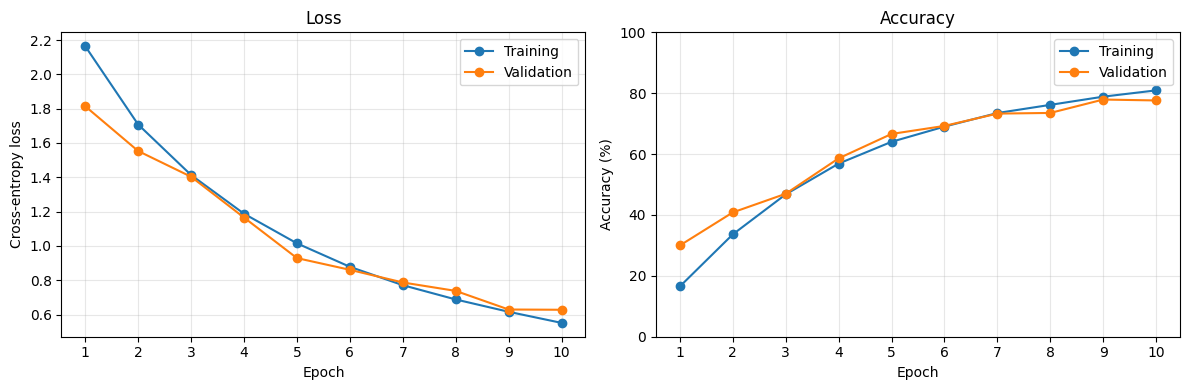

In [13]:
import matplotlib.pyplot as plt

epochs = [row["epoch"] for row in history]  # Reuse all ten recorded epochs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for prefix, label in [("train", "Training"), ("val", "Validation")]:
    losses = [row[f"{prefix}_loss"] for row in history]
    accuracies = [100 * row[f"{prefix}_accuracy"] for row in history]

    axes[0].plot(epochs, losses, marker="o", label=label)
    axes[1].plot(epochs, accuracies, marker="o", label=label)

axes[0].set_title("Loss")
axes[0].set_ylabel("Cross-entropy loss")

axes[1].set_title("Accuracy")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.set_xticks(epochs)
    axis.legend()
    axis.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(save_directory / "learning_curves.png", dpi=200)  # Save to Drive
plt.show()

In [14]:
best_checkpoint = torch.load(
    save_directory / "best.pt",
    map_location="cpu",
    weights_only=True
)

evaluation_model = AlexNetCIFAR10().to(device)  # Same architecture
evaluation_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)  # Replace initial parameters with the saved trained parameters

evaluation_model.eval()  # Disable dropout

print("Evaluating epoch:", best_checkpoint["epoch"])

Evaluating epoch: 9


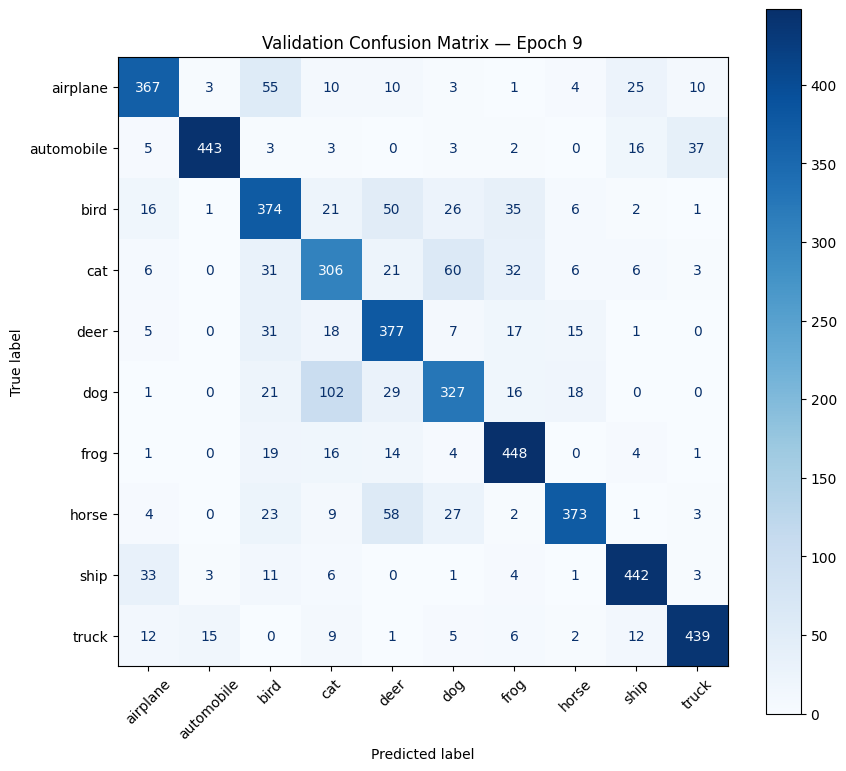

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

actual_labels = []
predicted_labels = []

with torch.no_grad():  # Evaluation only—no gradients or weight updates
    for images, labels in val_loader:
        outputs = evaluation_model(images.to(device))
        predictions = outputs.argmax(dim=1)  # Pick the highest-scoring class

        actual_labels.extend(labels.cpu().tolist())  # Store correct answers
        predicted_labels.extend(predictions.cpu().tolist())  # Store predictions

fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    actual_labels,
    predicted_labels,
    labels=list(range(10)),
    display_labels=full_training_dataset.classes,
    cmap="Blues",
    values_format="d",  # Display whole-number counts
    xticks_rotation=45,
    ax=ax
)

ax.set_title(f"Validation Confusion Matrix — Epoch {best_checkpoint['epoch']}")
fig.tight_layout()
fig.savefig(save_directory / "validation_confusion_matrix.png", dpi=200)
plt.show()

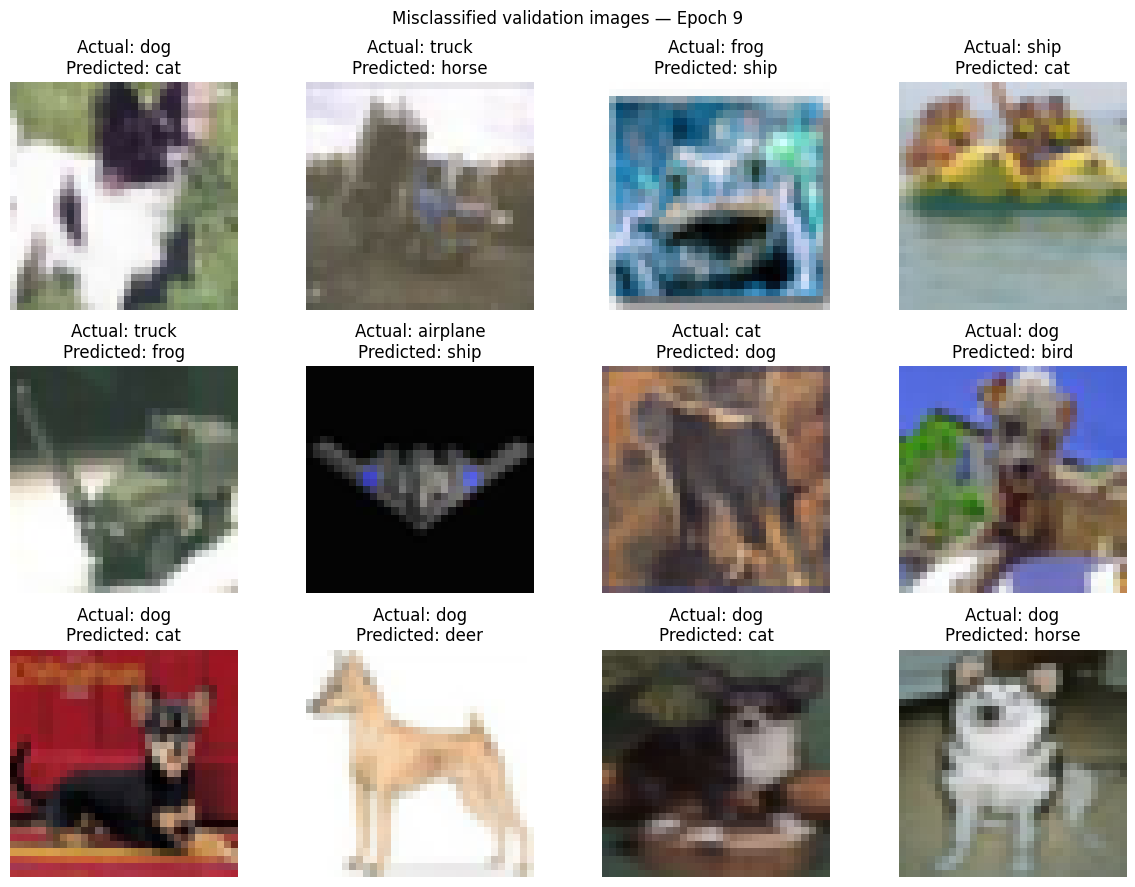

In [16]:
# Find positions where the prediction differs from the correct label
wrong_indices = []

for index in range(len(actual_labels)):
    if actual_labels[index] != predicted_labels[index]:
        wrong_indices.append(index)

# Convert numeric labels into names such as "cat" and "dog"
class_names = full_training_dataset.classes

# Create space for 12 images: 3 rows and 4 columns
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax in axes.flat:
    ax.axis("off")  # Hide tick marks and borders

# Display the first 12 mistakes
for ax, index in zip(axes.flat, wrong_indices[:12]):
    image, true_label = val_dataset[index]
    predicted_label = predicted_labels[index]

    # Undo our normalization: return pixel values from [-1, 1] to [0, 1]
    display_image = (image * 0.5 + 0.5).clamp(0, 1)

    # Change channels × height × width into height × width × channels
    display_image = display_image.permute(1, 2, 0).numpy()

    ax.imshow(display_image, interpolation="nearest")
    ax.set_title(
        f"Actual: {class_names[true_label]}\n"
        f"Predicted: {class_names[predicted_label]}"
    )

fig.suptitle("Misclassified validation images — Epoch 9")
fig.tight_layout()

# Save alongside the learning curves and confusion matrix
fig.savefig(save_directory / "misclassified_examples.png", dpi=200)
plt.show()

## Final held-out test evaluation

The checkpoint is selected using validation accuracy, then frozen before evaluating the official CIFAR-10 test partition.

For the original run, validation selected epoch 9. Its 77.92% validation accuracy is not a test result.

The following evaluation uses all 10,000 test images with the same preprocessing and dropout disabled. No weights are updated. Test results must not be used to choose a different epoch or tune this model.

Accuracy measures the fraction of correct predictions. Per-class precision, recall, and F1 reveal differences between classes. Macro F1 averages the ten class-level F1 scores equally.


In [17]:
import json
import pandas as pd
from sklearn.metrics import classification_report

# Reuse the selected checkpoint model from your confusion-matrix section
evaluation_model.eval()

test_dataset = datasets.CIFAR10(
    root=full_training_dataset.root,  # Reuse the existing dataset location
    train=False,                     # Official held-out test partition
    download=True,                   # Reuse valid files if already present
    transform=preprocess             # Exactly the same preprocessing
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

test_actual = []
test_predicted = []
test_loss_sum = 0.0

with torch.no_grad():  # No gradient calculation or weight updates
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = evaluation_model(images)
        loss = criterion(outputs, labels)

        # Account for the final, potentially smaller batch
        test_loss_sum += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        test_actual.extend(labels.cpu().tolist())
        test_predicted.extend(predictions.cpu().tolist())

assert len(test_actual) == 10000

test_correct = sum(
    actual == predicted
    for actual, predicted in zip(test_actual, test_predicted)
)

test_accuracy = test_correct / len(test_actual)
test_loss = test_loss_sum / len(test_actual)

class_names = full_training_dataset.classes

test_report = classification_report(
    test_actual,
    test_predicted,
    labels=list(range(10)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_macro_f1 = test_report["macro avg"]["f1-score"]

# Keep only the ten class rows for the class-by-class table
test_per_class = pd.DataFrame(test_report).T.loc[class_names].copy()
test_per_class["support"] = test_per_class["support"].astype(int)

print("Selected epoch:", best_checkpoint["epoch"])
print(f"Test accuracy: {test_accuracy:.2%} ({test_correct}/10000)")
print(f"Test loss: {test_loss:.4f}")
print(f"Macro F1: {test_macro_f1:.4f}")
print("Precision, recall, and F1 below are fractions from 0 to 1.")

display(test_per_class.round(4))

# Save the numerical evidence for your GitHub project
test_per_class.to_csv(
    report_directory / "test_per_class.csv",
    index_label="class"
)

pd.DataFrame(history).to_csv(
    report_directory / "training_history.csv",
    index=False
)

pd.DataFrame({
    "test_index": range(len(test_actual)),
    "actual": test_actual,
    "predicted": test_predicted
}).to_csv(report_directory / "test_predictions.csv", index=False)

results = {
    "selected_epoch": best_checkpoint["epoch"],
    "test_images": len(test_actual),
    "test_correct": test_correct,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "test_macro_f1": test_macro_f1,
    "classification_report": test_report
}

(report_directory / "test_results.json").write_text(
    json.dumps(results, indent=2),
    encoding="utf-8"
)

print("Reports saved to:", report_directory)

Selected epoch: 9
Test accuracy: 78.37% (7837/10000)
Test loss: 0.6373
Macro F1: 0.7842
Precision, recall, and F1 below are fractions from 0 to 1.


,precision,recall,f1-score,support
airplane,0.8131,0.757,0.7840,1000
automobile,0.9370,0.848,0.8903,1000
bird,0.6424,0.715,0.6768,1000
cat,0.6470,0.625,0.6358,1000
deer,0.6928,0.841,0.7597,1000
dog,0.7372,0.662,0.6976,1000
frog,0.7738,0.886,0.8261,1000
horse,0.9084,0.734,0.8119,1000
ship,0.8703,0.899,0.8844,1000
truck,0.8815,0.870,0.8757,1000


Reports saved to: /content/drive/MyDrive/alexnet-study/run_20260904_140401/report_20260905_130212_589246


## Final research conclusion

### Answer to the research question

The AlexNet-style CIFAR-10 model was trained for ten epochs, with checkpoint selection based only on validation accuracy. Epoch 9 was selected with **77.92% validation accuracy**.

When evaluated on the untouched test partition, the selected checkpoint achieved:

* **Test accuracy:** 78.37% (7,837/10,000 correct)
* **Test cross-entropy loss:** 0.6373
* **Macro F1 score:** 0.7842

Test accuracy was 0.45 percentage points higher than validation accuracy. The small difference shows that performance was similar across these two partitions, but one run cannot establish how much results would vary with different random initialization.

### Class-level findings

Performance was not uniform across the ten classes. The lowest F1 scores belonged to **cat (0.6358), bird (0.6768), and dog (0.6976)**. Cat also had the lowest recall, with only 62.5% of test cats classified correctly.

The strongest F1 scores belonged to **automobile (0.8903), ship (0.8844), and truck (0.8757)**.

Some classes showed different precision–recall behaviour. Deer recall was high at 84.1%, but precision was lower at 69.28%, indicating that non-deer images were sometimes predicted as deer. Horse precision was 90.84%, while recall was 73.4%, meaning horse predictions were usually correct but many actual horses were missed.

The validation confusion matrix also showed substantial confusion between dogs and cats. The test class metrics confirm that both remained among the more difficult classes, although a test confusion matrix would be needed to identify the exact test-set confusion directions.

### Main takeaways

* An AlexNet-style architecture can learn useful CIFAR-10 representations despite being adapted for much smaller images than the original AlexNet input.
* Aggregate accuracy alone does not describe model behaviour; class-level precision, recall, and F1 reveal concentrated weaknesses.
* Validation data was used for checkpoint selection, while the official test partition provided the final performance estimate.
* The project demonstrates model implementation, GPU training, checkpoint management, held-out evaluation, and evidence-based error analysis.

### Limitations

This is an AlexNet-style CIFAR-10 adaptation, not an exact reproduction of the original ImageNet results. The findings come from one training run, and the original initialization and shuffle seeds were not recorded. Training was initially planned for five epochs and later extended to ten, so the study was exploratory rather than preregistered.

No controlled architecture comparisons were performed. Therefore, the results do not establish the individual effects of dropout, ReLU, depth, or pooling. CIFAR-10 test performance also does not establish robustness to real-world distribution changes or demographic fairness.

The separate shortcut-bias notebook will investigate how a deliberately introduced visual cue affects model predictions. Its conclusions will be reported independently from this implementation study.
